In [1]:
import pandas as pd


df = pd.read_csv('train.csv')

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

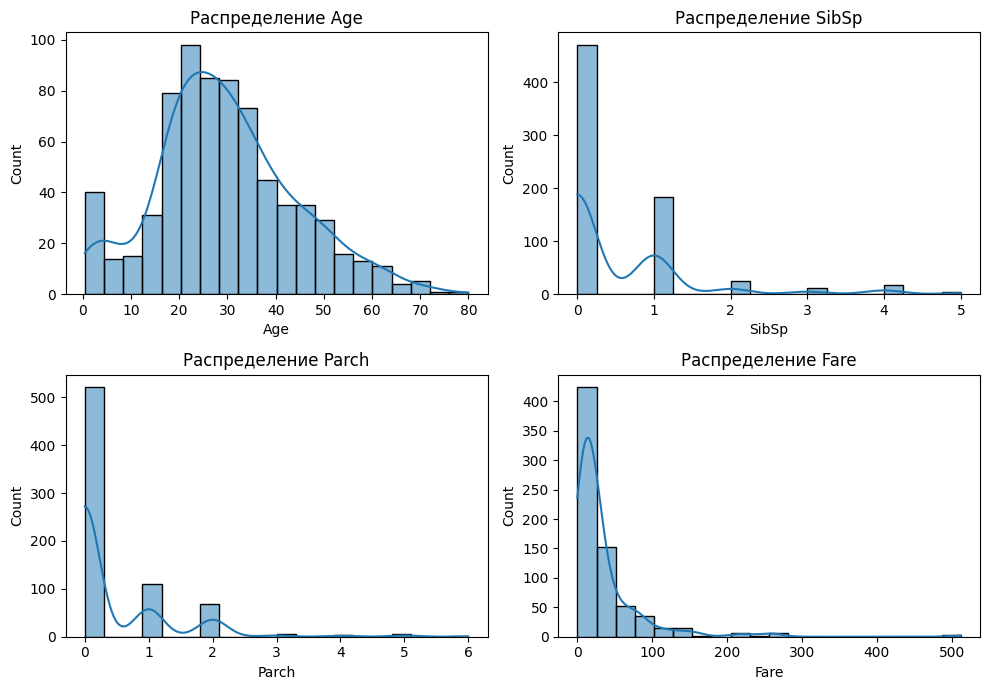

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


df_w_age = df.dropna(subset=['Age'])
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(df_w_age[feature], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {feature}')

plt.tight_layout()
plt.show()

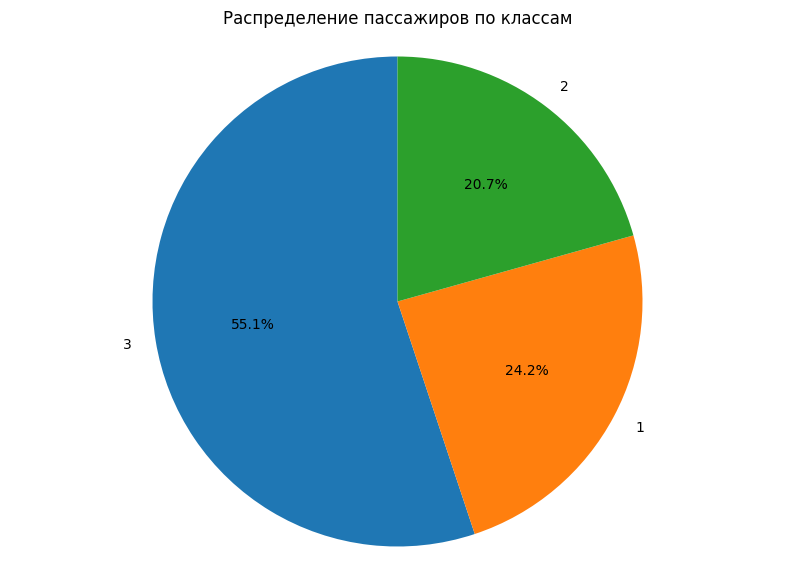

In [5]:
pclass_df = df['Pclass'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(pclass_df, labels=pclass_df.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение пассажиров по классам')
plt.axis('equal')
plt.show()

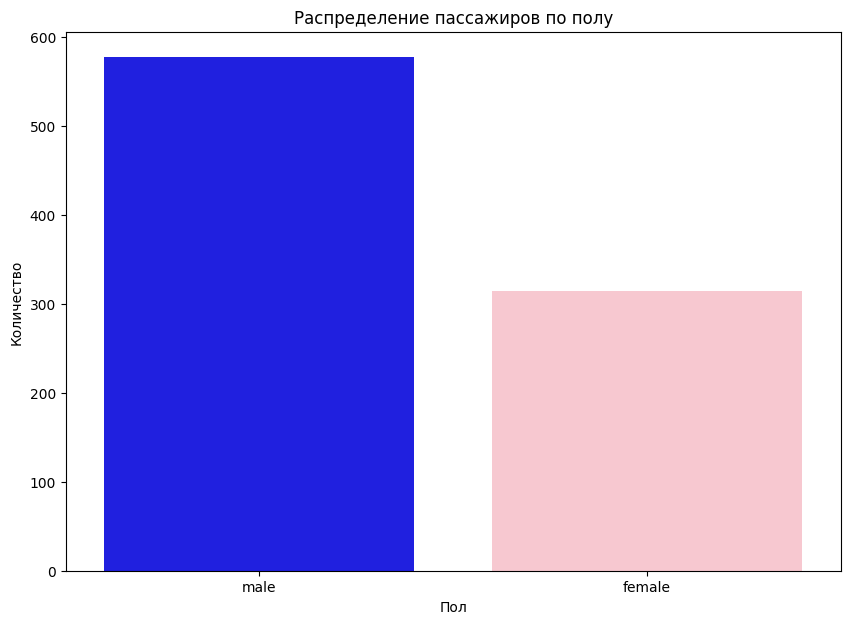

In [6]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Sex', hue='Sex', palette=['blue', 'pink'], legend=False)
plt.title('Распределение пассажиров по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

In [ ]:
corr = df_w_age.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций 1')
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df_w_age)

plt.title('Возраст по классу и полу')
plt.xlabel('Класс')
plt.ylabel('Возраст')
plt.legend(title='Пол')
plt.show()